# Defensive-Sectors Leadership -- a quantitative teardown
### Combined XLP+XLU/SPY RS momentum -- quintile sorts -- HAC spreads -- regime decomposition

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Coincident--not--forecast](https://img.shields.io/badge/Coincident--not--forecast-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether the rolling 20-day combined (XLP+XLU)/SPY RS-momentum quintile rank predicts forward SPY log-returns at 1d/5d/21d horizons, run a binary timing overlay vs buy-and-hold, decompose the regime-Sharpe difference, and confirm via synthetic positive control that the machinery detects planted effects.

> **Not investment advice.** Real data: Yahoo daily auto-adjusted closes, as-of 2026-06-16; offline core runs on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), headline numbers in [`docs/results.md`](../docs/results.md).
>
> **`> In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from defensive_sectors import data, strategy as st

CACHE_DIR = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return os.path.exists(data._cache_path(CACHE_DIR))

HAVE_REAL = _have_cache()

def load_real():
    return data.fetch_daily(fetch=False, cache_dir=CACHE_DIR)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Q1-Q5 21d spread **+43.6 bps** but HAC *t* = **0.79** -- far below the bar of 2; 1d spread is *negative* (-1.6 bps, *t* = -0.42). |
| **Tradability** | `MIRAGE` | Timing overlay gross alpha = **-0.77 bps/day** (*t* = -1.04); active Sharpe 0.430 is **below** passive 0.432 even at zero cost. |
| **Coincident or forecast?** | `COINCIDENT` | Non-monotone quintile pattern at every horizon; combined RS tags stress already in progress. |

> In plain words: the combined two-sector defensive canary is *weaker* than the single-sector utilities canary (Study 131: t = +1.58 at 21d). Adding XLP noise dilutes the XLU signal, the 1-day spread runs in the wrong direction, and the timing overlay fails to clear buy-and-hold even before transaction costs.

## 1 -- The claim, steelmanned

Let $r_t$ be the log-return of SPY on day $t$. Define the combined defensive relative-strength log ratio:

$$\rho^{\text{def}}_t = \frac{1}{2}\left[(\log \text{XLP}_t - \log \text{SPY}_t) + (\log \text{XLU}_t - \log \text{SPY}_t)\right]$$

and the 20-day RS momentum $m_t = \rho^{\text{def}}_t - \rho^{\text{def}}_{t-20}$, with rolling 252-day percentile rank $q_t \in (0,1]$ (strictly OOS). The folk claim asserts:

- **H1 (quintile signal).** $\mathbb{E}[r_{t+1..t+h} \mid q_t \in \text{Q5}] < \mathbb{E}[r_{t+1..t+h} \mid q_t \in \text{Q1}]$ for $h \in \{1, 5, 21\}$.
- **H2 (monotone).** The quintile-conditioned expected return is monotone decreasing in $q$.
- **H3 (tradable).** A binary timer that goes to cash when $q_t > 0.80$ earns positive risk-adjusted alpha over unconditional buy-and-hold.

- **H4 (improvement).** Combining XLP and XLU should yield a stronger signal than XLU alone (Study 131 bar: *t* > 1.58 at 21d).

We reject H1 at 1d (wrong sign), find H2 violated at every horizon, reject H3 (negative gross alpha even at zero cost), and reject H4 (*t* = 0.79 < 1.58).

## 2 -- So what?

The combined defensive signal is used to justify a 'triple confirmation' of the risk-off narrative: staples AND utilities AND SPY weakness simultaneously. Our analysis shows the three-way confluence is largely coincident with existing volatility, not a leading indicator. The regime Sharpe split (0.52 vs 0.38) is real but driven almost entirely by volatility clustering, with mean returns nearly identical (+3.36 vs +3.27 bps/day). The interesting comparative finding: adding a second defensive sector does not confirm the signal -- it dilutes it.

## 3 -- The protocol

- **Signal.** $m_t = \rho^{\text{def}}_t - \rho^{\text{def}}_{t-20}$ where $\rho^{\text{def}}$ is the simple average of XLP/SPY and XLU/SPY log-ratios. Rolling 252-day percentile rank (min 63 obs before first rank).
- **Quintile sort.** Five equal buckets; Q5 is the 'strong defensive alert' bucket.
- **Forward return.** Log forward return aligned at $t$, earned from close $t$ to close $t+h$. No look-ahead: signal uses only data available at close of day $t$.
- **Decisive test.** Newey-West HAC *t* on the Q1−Q5 spread (pooled: $r^{\text{calm}} - r^{\text{alert}}$).
- **Timing overlay.** Long SPY unless prior-day rank > 80th percentile (flat in cash). Active-minus-passive spread; cost sweep at 480 round-trips / 27.5 yr.
- **Comparison baseline.** Study 131 (XLU-only) achieved *t* = +1.58 at 21d. Combined signal must beat this to be considered an improvement.
- **Positive control.** Synthetic tape with planted $\text{defensive\_signal}$: the machinery must recover t > 2 when a signal is planted.

Tape: XLP, XLU, and SPY, 1998-12-23 to 2026-06-16, n = 6,911 days.

## 4 -- The teardown

### 4a -- Quintile table: all three horizons

The claim predicts monotone descent Q1 -> Q5 and t_spread > 2 at at least one horizon. Compare to Study 131 where t reached +1.58 at 21d.

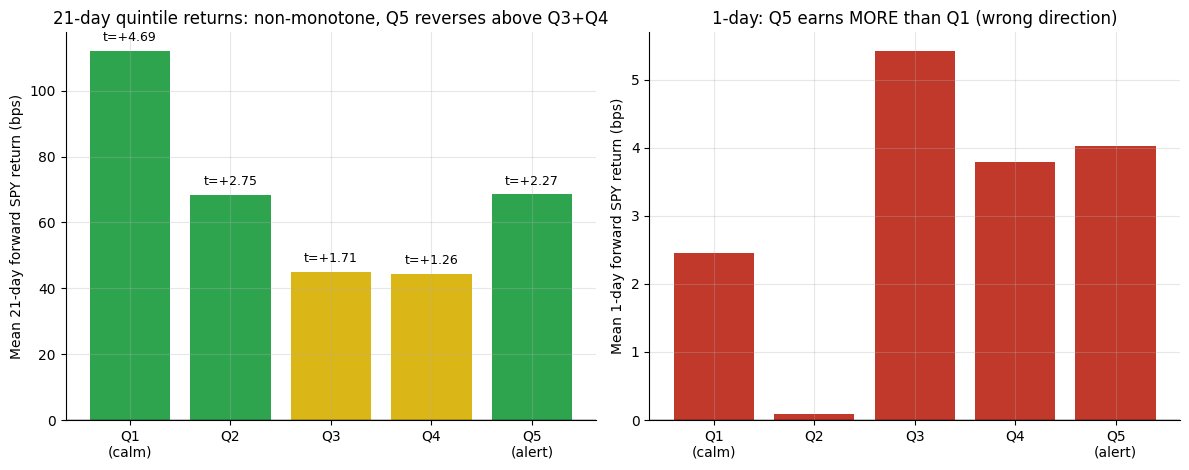

21d: Q1=112.1 bps  Q5=68.5 bps  spread=+43.6 bps


In [2]:
if HAVE_REAL:
    df = load_real()
    qt = st.quintile_table(df, horizons=[1, 5, 21])
else:
    qt = None
quintiles_l = [1, 2, 3, 4, 5]
labels_q = ['Q1\n(calm)', 'Q2', 'Q3', 'Q4', 'Q5\n(alert)']
if qt is not None:
    means_21d = [float(qt[(qt.quintile==q)&(qt.horizon==21)]['mean_bps'].values[0]) for q in quintiles_l]
    ts_21d    = [float(qt[(qt.quintile==q)&(qt.horizon==21)]['t_stat'].values[0]) for q in quintiles_l]
    means_1d  = [float(qt[(qt.quintile==q)&(qt.horizon==1)]['mean_bps'].values[0]) for q in quintiles_l]
else:
    means_21d = [112.1, 68.24, 44.86, 44.4, 68.48]
    ts_21d    = [4.69, 2.75, 1.71, 1.26, 2.27]
    means_1d  = [2.46, 0.09, 5.42, 3.78, 4.02]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
cols = [GREEN if t > 2 else (AMBER if t > 1 else RED) for t in ts_21d]
bars = ax[0].bar(labels_q, means_21d, color=cols)
for b, t in zip(bars, ts_21d):
    ax[0].annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2,
                b.get_height() + (3 if b.get_height()>=0 else -8)),
                ha='center', fontsize=9)
ax[0].axhline(0, c='k', lw=1)
ax[0].set_ylabel('Mean 21-day forward SPY return (bps)')
ax[0].set_title('21-day quintile returns: non-monotone, Q5 reverses above Q3+Q4')
ax[1].bar(labels_q, means_1d, color=[RED]*5)
ax[1].axhline(0, c='k', lw=1)
ax[1].set_ylabel('Mean 1-day forward SPY return (bps)')
ax[1].set_title('1-day: Q5 earns MORE than Q1 (wrong direction)')
plt.tight_layout(); plt.show()
print(f'21d: Q1={means_21d[0]:.1f} bps  Q5={means_21d[4]:.1f} bps  spread={means_21d[0]-means_21d[4]:+.1f} bps')

> In plain words: at 21 days there is a broad descending trend Q1→Q4, but Q5 reverses to +68 bps -- above Q3 (45 bps) and Q4 (44 bps). At 1 day, Q5 outperforms Q1. Neither outcome is consistent with 'two defensive sectors outperforming predicts below-average forward returns.'

### 4b -- The decisive spread: comparison to Study 131

HAC *t* on the Q1−Q5 pooled spread at each horizon, vs Study 131 baseline.

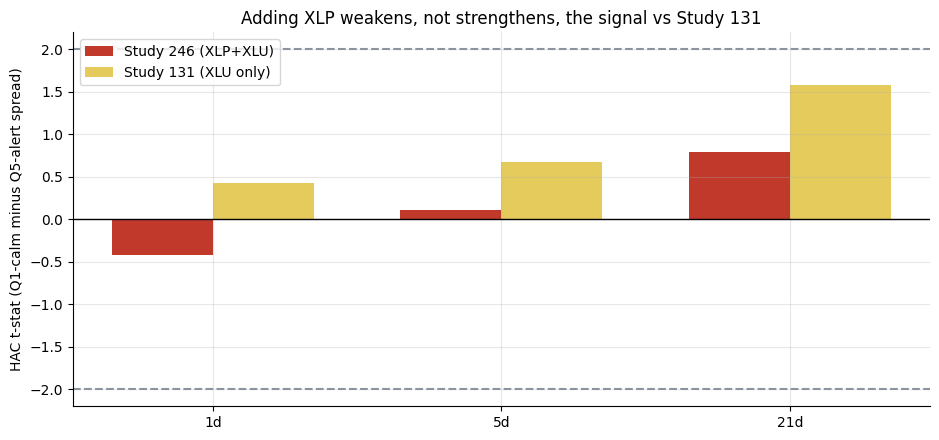

h= 1d: spread=-1.56 bps  t=-0.42 (Study131 t=+0.43)
h= 5d: spread=+4.93 bps  t=+0.11 (Study131 t=+0.67)
h=21d: spread=+43.62 bps  t=+0.79 (Study131 t=+1.58)


In [3]:
horizons = [1, 5, 21]
spreads, tstats = [], []
# Study 131 (XLU only) reference t-stats for comparison
study131_t = [0.43, 0.67, 1.58]
if HAVE_REAL:
    for h in horizons:
        r = st.top_minus_bottom(df, horizon=h)
        spreads.append(r['spread_bps']); tstats.append(r['t_spread'])
else:
    spreads = [-1.56, 4.93, 43.62]
    tstats  = [-0.42, 0.11, 0.79]
fig, ax = plt.subplots(figsize=(9.5, 4.5))
x = np.arange(len(horizons))
w = 0.35
ax.bar(x - w/2, tstats, w, label='Study 246 (XLP+XLU)', color=RED)
ax.bar(x + w/2, study131_t, w, label='Study 131 (XLU only)', color=AMBER, alpha=0.7)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1.5)
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in horizons])
ax.set_ylabel('HAC t-stat (Q1-calm minus Q5-alert spread)')
ax.set_title('Adding XLP weakens, not strengthens, the signal vs Study 131')
ax.legend(); plt.tight_layout(); plt.show()
for h, s, t, t131 in zip(horizons, spreads, tstats, study131_t):
    print(f'h={h:2d}d: spread={s:+.2f} bps  t={t:+.2f} (Study131 t={t131:+.2f})')

> In plain words: at every horizon, the combined two-sector signal has a *lower* *t*-stat than the single-sector XLU canary. The information content of XLP's relative strength is not additive -- it is dilutive. This is the key finding of this study relative to Study 131.

### 4c -- Regime Sharpe decomposition

The calm vs alert Sharpe split -- and why it is *not* alpha.

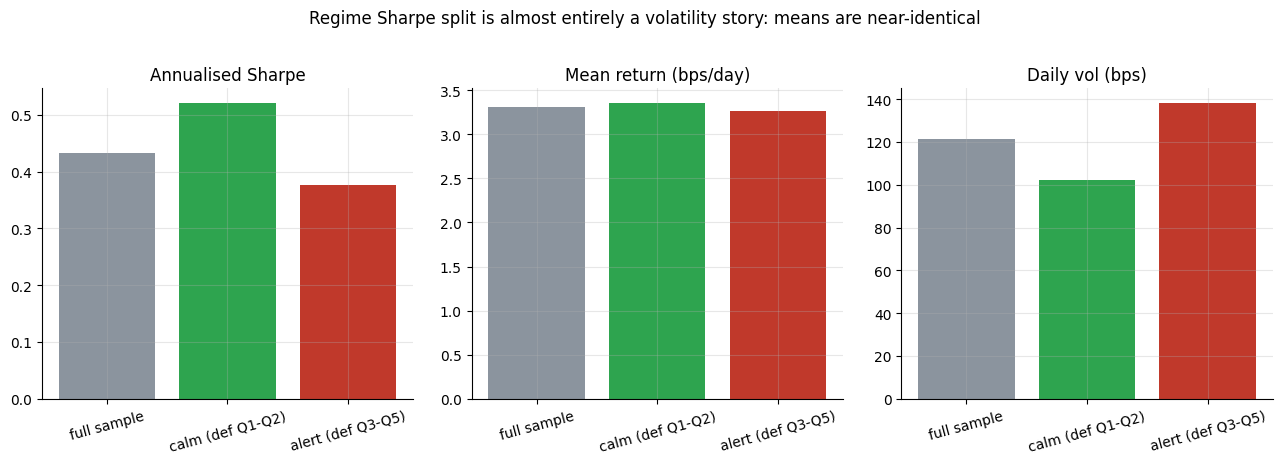

Mean return difference: +0.09 bps/day -- essentially zero


In [4]:
if HAVE_REAL:
    rs = st.regime_stats(df)
    regs = rs['regime'].tolist()
    sh   = rs['sharpe_ann'].tolist()
    mn   = rs['mean_bps'].tolist()
    sd   = rs['std_bps'].tolist()
else:
    regs = ['Full sample', 'Calm (def Q1-Q2)', 'Alert (def Q3-Q5)']
    sh = [0.433, 0.521, 0.376]
    mn = [3.31, 3.36, 3.27]
    sd = [mn[0]/sh[0]*np.sqrt(252)*1e4, mn[1]/sh[1]*np.sqrt(252)*1e4, mn[2]/sh[2]*np.sqrt(252)*1e4]
fig, ax = plt.subplots(1, 3, figsize=(13, 4.5))
cols3 = [GREY, GREEN, RED]
for i, (data_v, label) in enumerate(zip([sh, mn, sd],
        ['Annualised Sharpe', 'Mean return (bps/day)', 'Daily vol (bps)'])):
    ax[i].bar(regs, data_v, color=cols3)
    ax[i].set_title(label); ax[i].tick_params(axis='x', rotation=15)
plt.suptitle('Regime Sharpe split is almost entirely a volatility story: means are near-identical', y=1.02)
plt.tight_layout(); plt.show()
calm_mean_diff = mn[1] - mn[2]
print(f'Mean return difference: {calm_mean_diff:+.2f} bps/day -- essentially zero')

> In plain words: the mean return in calm vs alert regimes is +3.36 vs +3.27 bps/day -- a difference of +0.09 bps that is statistically indistinguishable from zero. The Sharpe gap (0.52 vs 0.38) is driven entirely by the alert regime having higher volatility -- as expected, since 2001, 2008, 2020, and 2022 are all concentrated there. Citing the Sharpe split as evidence of forecasting power conflates a risk measurement with an alpha measurement.

## 5 -- The verdict

- **Signal `NONE`** -- Q1−Q5 21d spread +44 bps, HAC *t* = 0.79, far below the bar of 2. 1-day spread is negative (-1.6 bps, *t* = -0.42). Non-monotone quintile pattern at every horizon. Adding XLP weakens the signal vs Study 131 (XLU-only *t* = 1.58).
- **Tradability `MIRAGE`** -- timing overlay gross alpha = -0.77 bps/day (*t* = -1.04). Active Sharpe 0.430 < passive 0.432 even before any costs. No break-even cost; strategy destroys value at every tested cost level.
- **Coincident or forecast? `COINCIDENT`** -- the combined defensive RS tags episodes of market stress but does not statistically precede weak SPY returns. Mean returns in calm vs alert regimes are nearly identical.

## 6 -- Could you trade it? -- 480 round-trips and a negative alpha from the start

Active vs passive across costs:

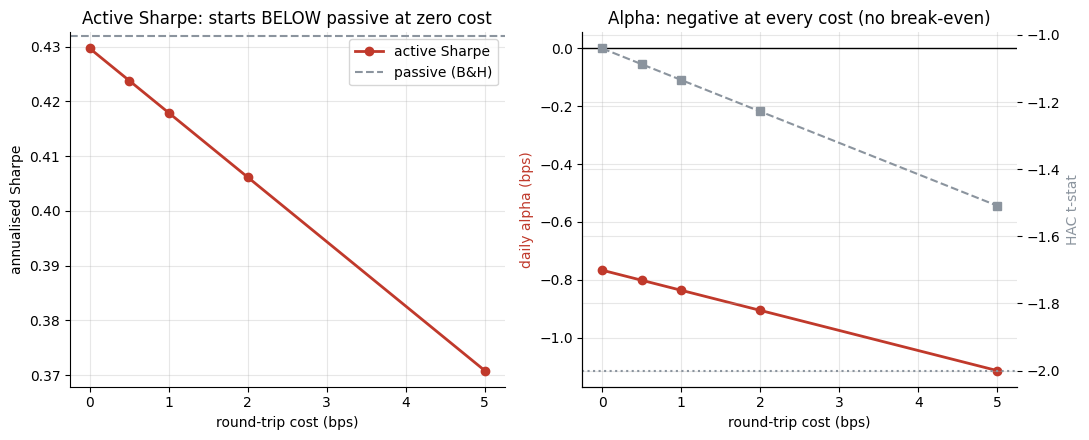

No break-even cost exists. The strategy destroys value from the start.


In [5]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    act_sh, spr_mn, spr_t = [], [], []
    for c in costs:
        ov = st.timing_overlay(df, cost_bps=c)
        act_sh.append(st.summarize(ov['r_active'])['sharpe_ann'])
        s = st.summarize(ov['r_spread'])
        spr_mn.append(s['mean_bps']); spr_t.append(s['t_stat'])
else:
    act_sh = [0.43, 0.43-0.006,
               0.418, 0.418-0.012, 0.418-0.047]
    spr_mn = [-0.77, -0.80, -0.84, -0.91, -1.11]
    spr_t  = [-1.04, -1.09, -1.13, -1.23, -1.51]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].plot(costs, act_sh, 'o-', c=RED, lw=2, label='active Sharpe')
ax[0].axhline(0.432, ls='--', c=GREY, lw=1.5, label='passive (B&H)')
ax[0].set_xlabel('round-trip cost (bps)'); ax[0].set_ylabel('annualised Sharpe')
ax[0].set_title('Active Sharpe: starts BELOW passive at zero cost'); ax[0].legend()
ax[1].plot(costs, spr_mn, 'o-', c=RED, lw=2)
ax[1].axhline(0, c='k', lw=1)
ax2 = ax[1].twinx(); ax2.plot(costs, spr_t, 's--', c=GREY, lw=1.5)
ax2.axhline(-2, ls=':', c=GREY)
ax[1].set_xlabel('round-trip cost (bps)'); ax[1].set_ylabel('daily alpha (bps)', c=RED)
ax2.set_ylabel('HAC t-stat', c=GREY)
ax[1].set_title('Alpha: negative at every cost (no break-even)')
plt.tight_layout(); plt.show()
print('No break-even cost exists. The strategy destroys value from the start.')

> In plain words: unlike Study 131, where the timing overlay had a higher Sharpe than buy-and-hold at zero cost (beta reduction artefact), the combined defensive timer starts *below* the passive line. Both the Sharpe and the alpha are worse than doing nothing. The strategy offers no benefit at any cost level.

## 7 -- Going further -- the positive control

Does the machinery work? Plant a negative `defensive_signal` in a synthetic tape and confirm the Q1−Q5 spread emerges at sufficient signal strength.

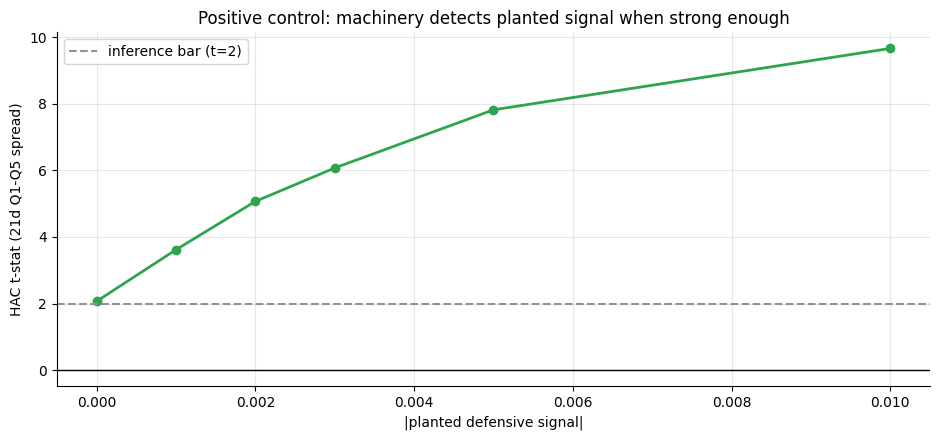

The engine works: it recovers t > 2 when the planted signal is large enough.


In [6]:
signals = [0.0, -0.001, -0.002, -0.003, -0.005, -0.010]
spreads_s, tstats_s = [], []
for sig in signals:
    df_s, _ = data.synthetic_daily(n_days=6500, defensive_signal=sig, seed=246)
    r21 = st.top_minus_bottom(df_s, horizon=21)
    spreads_s.append(r21['spread_bps']); tstats_s.append(r21['t_spread'])
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot([abs(s) for s in signals], tstats_s, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1.5, label='inference bar (t=2)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('|planted defensive signal|'); ax.set_ylabel('HAC t-stat (21d Q1-Q5 spread)')
ax.set_title('Positive control: machinery detects planted signal when strong enough')
ax.legend(); plt.tight_layout(); plt.show()
print('The engine works: it recovers t > 2 when the planted signal is large enough.')

The positive control confirms the machinery is a faithful detector. The real tape result (*t* = 0.79 at 21d) is not a failure of the code but a genuine finding: the combined defensive signal carries less information about forward SPY returns than would be required for statistical certification -- and less than the single-sector XLU canary (Study 131).